CSV に書き出しました: ./R_results/R_summary_doy286_L1_withT.csv


/tmp/ipykernel_28816/779869770.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(infile, comment='#', delim_whitespace=True, header=None)


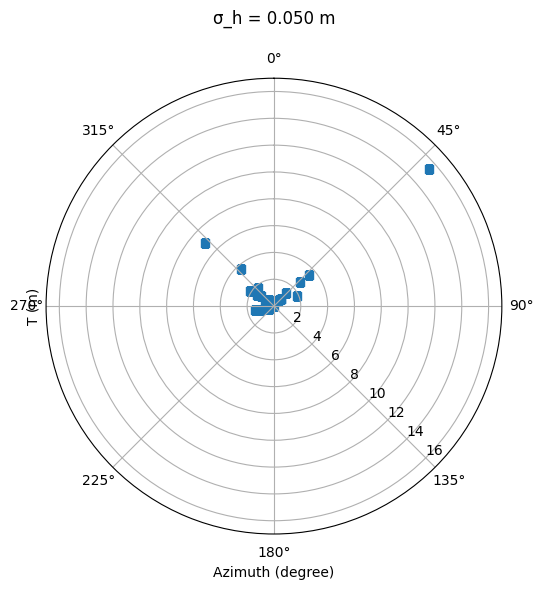

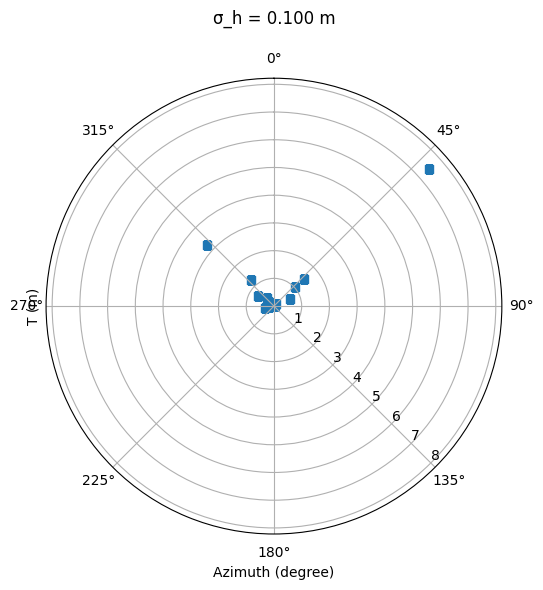

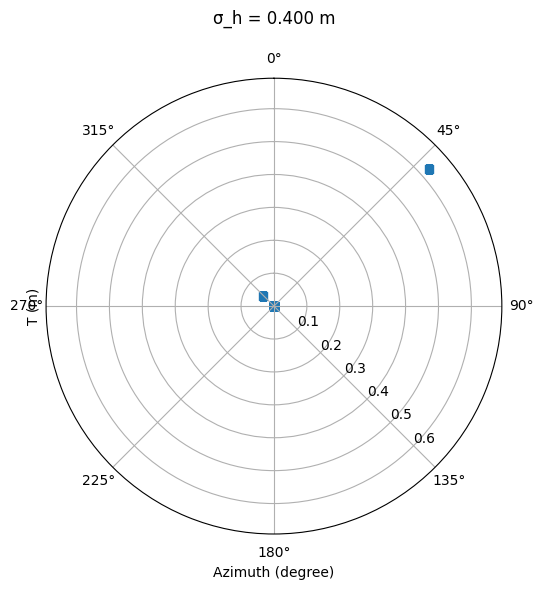

In [8]:
import math
import numpy as np
import pandas as pd
import mpmath as mp
import matplotlib.pyplot as plt

# ========================
# 1. 入力・パラメータ設定
# ========================

infile = "./R_results/R_summary_doy286_L1.res"   # さっきの .res ファイル
outfile = "./R_results/R_summary_doy286_L1_withT.csv" # 出力ファイル

# GNSS L1 の波長 [m]（必要なら変えてください）
lam_L1 = 0.190293672798365

# 一度に見たい σ_h [m] のリスト
sigma_list = [0.05, 0.10, 0.40]  # 例：5 cm, 10 cm, 40 cm

# ======================
# 2. データ読み込み
# ======================

df = pd.read_csv(infile, comment='#', delim_whitespace=True, header=None)
df.columns = [
    "doy", "sat", "sig_code",
    "az_mid_deg", "e_mid_deg",
    "R_mid_lin", "R_mid_dB",
    "R_int_lin", "R_int_dB",      # ★ ここを追加
    "t_start_hour", "t_end_hour",
    "e_start_deg", "e_end_deg",
    "h0_m",
]

# ==========================
# 3. Beckmann から T を計算
# ==========================

def S_of_g(g):
    """S(g) = sum_{m>=1} g^m/(m! m) を Ei で計算"""
    return float(mp.ei(g) - mp.euler - mp.log(g))

def compute_T_for_sigma(df, sigma_h, lam):
    """与えた σ_h に対する各行の T を返す"""
    eps_rad = np.deg2rad(df["e_mid_deg"].values)  # 衛星仰角 ε [rad]
    h = df["h0_m"].values
    R = df["R_mid_lin"].values

    # フレネル面積 A ≈ π λ h / sin ε
    A = math.pi * lam * h / np.sin(eps_rad)

    # g = (4π σ_h sin ε / λ)^2
    g = (4.0 * math.pi * sigma_h * np.sin(eps_rad) / lam) ** 2

    # S(g)
    S_vals = np.array([S_of_g(gi) for gi in g])

    # T^2 = A R / (π S(g))
    T_sq = A * R / (math.pi * S_vals)
    T = np.sqrt(T_sq)

    return T

# =====================================
# 4. σ_h ごとの T を df に追加して CSV 出力
# =====================================

for sigma_h in sigma_list:
    T_vals = compute_T_for_sigma(df, sigma_h, lam_L1)
    # 列名例: T_sigma_0p050m, T_sigma_0p100m, ...
    colname = f"T_sigma_{sigma_h:.3f}m".replace('.', 'p')
    df[colname] = T_vals

df.to_csv(outfile, index=False)

print("CSV に書き出しました:", outfile)

# ==========================
# 5. σ_h ごとに極座標プロット
# ==========================

for sigma_h in sigma_list:
    colname = f"T_sigma_{sigma_h:.3f}m".replace('.', 'p')
    T_vals = df[colname].values
    az_deg = df["az_mid_deg"].values

    # 無効値があれば落とす
    mask = np.isfinite(T_vals) & (T_vals >= 0)
    T_plot = T_vals[mask]
    az_plot = az_deg[mask]

    theta = np.deg2rad(az_plot)  # Azimuth [deg] → [rad]

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="polar")

    # 0° を北、時計回り
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.scatter(theta, T_plot, marker='s')

    ax.set_title(f"σ_h = {sigma_h:.3f} m", pad=20)
    ax.set_xlabel("Azimuth (degree)")
    ax.set_ylabel("T (m)")

    rmax = np.nanmax(T_plot) * 1.1 if len(T_plot) > 0 else 1.0
    ax.set_rmax(rmax)
    ax.set_rlabel_position(135)

    plt.tight_layout()
    plt.show()
